In [1]:
# 1. Import thư viện

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

In [2]:
# 2. Đọc dataset

df = pd.read_csv("data/diabetes_binary_health_indicators_BRFSS2015.csv")

print("Kích thước dataset:", df.shape)
display(df.head())

print("\nPhân bố nhãn Diabetes_binary:")
print(df["Diabetes_binary"].value_counts(normalize=True))

Kích thước dataset: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0



Phân bố nhãn Diabetes_binary:
Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64


In [3]:
# 3. Tiền xử lý & chia dữ liệu

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"].astype(int)

# Chia train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Tỷ lệ bệnh trong train:", y_train.mean())

Train: (202944, 21) | Test: (50736, 21)
Tỷ lệ bệnh trong train: 0.13933400346893723


In [9]:
# 4. Tạo pipeline
from imblearn.over_sampling import RandomOverSampler

pipeline = ImbPipeline(
    steps=[
        ("smote", SMOTE(random_state=42, sampling_strategy=0.4)),
        (
            "model",
            XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="aucpr",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)

In [10]:
pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,0.4
,random_state,42
,k_neighbors,5
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


Classification Report:
              precision    recall  f1-score   support

           0      0.916     0.889     0.902     43667
           1      0.418     0.494     0.453      7069

    accuracy                          0.834     50736
   macro avg      0.667     0.691     0.677     50736
weighted avg      0.846     0.834     0.839     50736



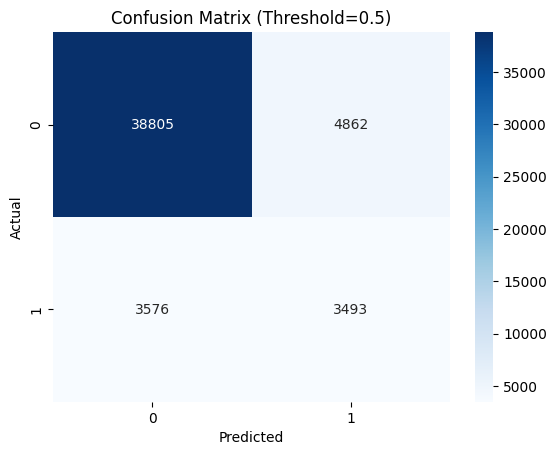

ROC-AUC: 0.825


In [6]:
# ===========================
# 6. Đánh giá mô hình (Threshold = 0.5)
# ===========================
proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = (proba >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Threshold=0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

roc = roc_auc_score(y_test, proba)
print(f"ROC-AUC: {roc:.3f}")

In [ ]:
# ===========================
# 7. Đánh giá mô hình trên Test
# ===========================
proba_test = pipeline.predict_proba(X_test)[:, 1]
y_pred_custom = (proba_test >= best_threshold).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred_custom, digits=3))

cm = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix (Recall≈{target_recall})")
plt.xlabel("Thật")
plt.ylabel("Dự đoán")
plt.show()

roc = roc_auc_score(y_test, proba_test)
print(f"ROC-AUC: {roc:.3f}")

NameError: name 'best_threshold' is not defined